# Training an MLP on Time Series Data
This notebook demonstrates how to train a Multi-Layer Perceptron (MLP) network using the 3W dataset for Multiclass Classification with Time Series data using the ThreeWToolkit.

### Imports
We start by importing the required libraries and classes from the Toolkit. 

In [1]:
from ThreeWToolkit.trainer import TorchTrainerConfig
from ThreeWToolkit.models import MLPConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import (
    SequentialPreprocessingAdapterConfig,
    FillLabelsConfig,
    CleanSignalsConfig,
    ImputeMissingConfig,
    NormalizeConfig,
    RemapClassConfig,
)
from ThreeWToolkit.feature_extraction import (
    SequentialFeatureAdapterConfig,
    WindowingConfig,
    ConcatFeatureAdapterConfig,
    StatisticalConfig,
    EWStatisticalConfig,
    WaveletConfig,
)
from ThreeWToolkit.assessment import (
    AssessmentVisualizationConfig,
    ModelAssessmentConfig,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 2026

### Loading and preparing the dataset

The next step is to create a ParqueDataset instance to interact with the *3W dataset*, for that we have to define a path location where we want to save the Dataset to (or where it is already located).

In [2]:
# Modify this path to the folder where your dataset is downloaded
dataset_path = "../../dataset"

ds_train = ParquetDatasetConfig(
    path=dataset_path, event_type=["real"], target_class=[0, 1, 2, 3]
).build()
print(f"Train dataset size: {len(ds_train)}")

ds_val = ParquetDatasetConfig(
    path=dataset_path, event_type=["simulated"], target_class=[0, 1, 2, 3]
).build()
print(f"Validation dataset size: {len(ds_val)}")

ds_test = ParquetDatasetConfig(
    path=dataset_path, event_type=["drawn"], target_class=[0, 1, 2, 3]
).build()
print(f"Test dataset size: {len(ds_test)}")

2026-04-09 12:31:42,802 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-09 12:31:42,804 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-09 12:31:42,805 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-09 12:31:42,896 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-09 12:31:42,897 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-09 12:31:42,898 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-09 12:31:42,936 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-09 12:31:42,937 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-09 12:31:42,938 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Train dataset size: 652
Validation dataset size: 204
Test dataset size: 10


In [3]:
window_size = 128
dataset_processor = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[
            CleanSignalsConfig(missing_column_threshold=1.1),
            ImputeMissingConfig(),
            NormalizeConfig(),
            FillLabelsConfig(),
            RemapClassConfig(),
        ]
    ),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=window_size),
            ConcatFeatureAdapterConfig(
                steps=[StatisticalConfig()]  # , EWStatisticalConfig(), WaveletConfig()
            ),
        ]
    ),
).build()

dataset_processor.fit(ds_train)
ds_train_transformed = dataset_processor.transform(ds_train)
ds_val_transformed = dataset_processor.transform(ds_val)
ds_test_transformed = dataset_processor.transform(ds_test)

### Model Trainer Configurations

With the data ready, we are now able to define the **ModelTrainer**, using using the MLPConfig and *TrainerConfig* configuration classes.

- Very important to note that the *TrainerConfig* class receives as a parameter the model configuration (config_model), and we use this information to instantiate **ModelTrainer**.   

In [4]:
mlp_config = MLPConfig(
    hidden_sizes=(32, 16),
    output_size=dataset_processor.num_classes,
)

trainer = TorchTrainerConfig(
    seed=RANDOM_SEED,
    config_model=mlp_config,
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
).build()

2026-04-09 12:32:43,918 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=2026
2026-04-09 12:32:43,918 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cuda | epochs=10 | batch_size=64


### Training the model

With the data and Trainer ready, we can call the *trainer.train()* method while passing the train_dataset and val_dataset argument. 

In [5]:
train_results = trainer.train(
    train_dataset=ds_train_transformed, val_dataset=ds_val_transformed
)

2026-04-09 12:32:43,928 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=652 | val_size=204
2026-04-09 12:32:44,149 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-09 12:32:44,154 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-09 12:32:44,155 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=652)
2026-04-09 12:33:17,519 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=1636
2026-04-09 12:33:17,521 | INFO | ThreeWToolkit.core.base_trainer | Preparing validation data...
2026-04-09 12:33:17,522 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=204)
2026-04-09 12:33:47,805 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=1595
2026-04-09 12:33:47,810 | INFO | ThreeWToolkit.core.base_trainer | Initializing training state...
2026-04-09 12:33:48,042 | INFO | ThreeWToolkit.trainer.torch_t

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

2026-04-09 12:34:37,618 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully


### Training Assessment and Results
For gathering the results using the test set, we will use the ModelAssessmentConfig inside a the *trainer.assess* method. 

In [6]:
test_results = trainer.predict(ds_test_transformed)

# Evaluate model performance on validation set using ModelTrainer's test method
assessment = ModelAssessmentConfig(
    metrics=["accuracy"],
).build()

results = assessment.evaluate(training_results=train_results, predictions=test_results)

2026-04-09 12:34:37,641 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=10)
2026-04-09 12:34:39,283 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=67
2026-04-09 12:34:39,392 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /home/eduardo/hold_new_code/3W/toolkit/output/exp_20260409_1234
2026-04-09 12:34:39,393 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: MLP
Task Type: classification
Timestamp: 20260409_1234

Metrics:
  accuracy: 0.1578

Training History:
  Final train_loss: 0.0436
  Final val_loss: 22.4577


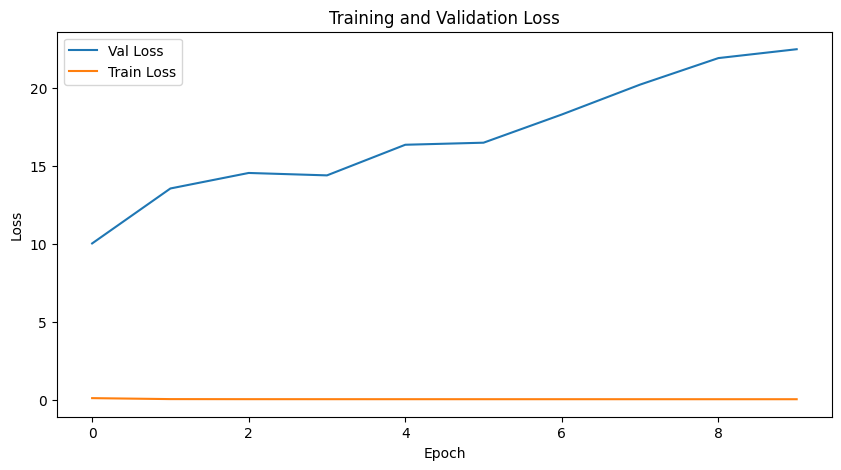

In [7]:
history = train_results.history
plt.figure(figsize=(10, 5))
plt.plot(history.val_loss, label="Val Loss")
plt.plot(history.train_loss, label="Train Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

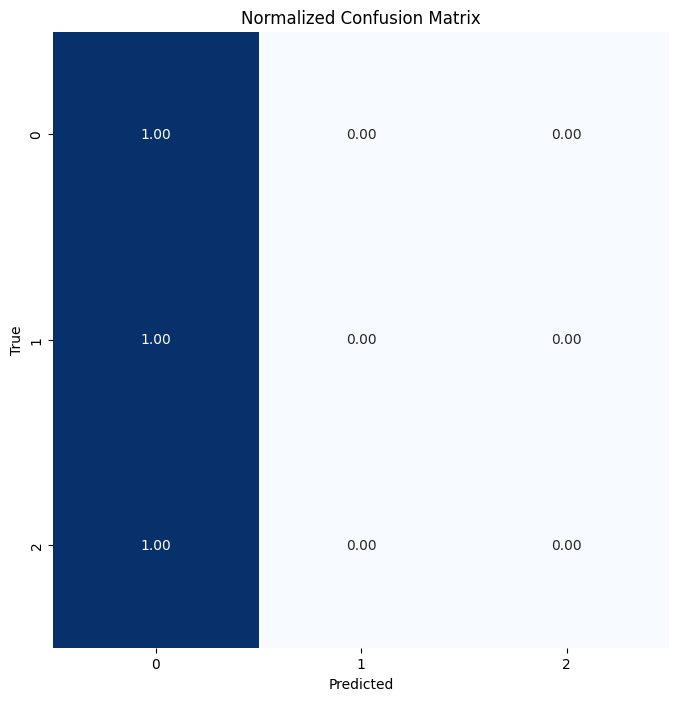

In [8]:
# Visualize training history
plotter = AssessmentVisualizationConfig().build()
fig = plotter.plot_confusion_matrix(
    y_true=test_results.y_true,
    y_pred=test_results.y_pred,
    normalize=True,
    title="Normalized Confusion Matrix",
)

__________